# Arc No / Arc Type Plot

`merge_rinex_sp3()` / `main.py` ile üretilen birleşik veri setini okuyup, seçili bir uydu ve gözlem tipi için
**epoch vs elevation** grafiği çiziyoruz. Her arc ayrı renkle gösterilir; arc başlangıç noktaları
işaretlenir ve `arcType` değerine göre yükselen/alçalan yön belirtilir.

Veri setindeki sütunlar:
`epoch`, `constellation`, `satID`, `arcNo`, `arcType`, `obsType`, `obsValue`, `elevation`, `azimuth`

Ön koşul: `data/processed/PTLD00AUS_2022001_30S.parquet` dosyası mevcut olmalı
(`python main.py` ile üretilir).

In [1]:
import os
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

%matplotlib inline

In [2]:
# --- AYARLAR ---
ARC_PARQUET = os.path.join(
    PROJECT_ROOT, "data", "processed", "PTLD00AUS_2022001_30S.parquet"
)
TARGET_SAT = "G05"       # İncelenecek uydu (örn. G05, R10, C06)
TARGET_OBS_TYPE = "S1C"  # Arc'lar obsType bazında hesaplanır
MIN_ELEVATION = 0.0      # Ufuk altı verileri grafikten çıkarmak için (derece)

if not os.path.isfile(ARC_PARQUET):
    raise FileNotFoundError(
        f"Islenmis parquet dosyasi bulunamadi: {ARC_PARQUET}\nOnce `python main.py` calistirin."
    )

df = pd.read_parquet(ARC_PARQUET)

print(f"Okunan dosya           : {ARC_PARQUET}")
print(f"Toplam satir sayisi    : {len(df)}")
print(f"Uydu sayisi            : {df['satID'].nunique()}")
print(f"Epok araligi           : {df['epoch'].min()}  ->  {df['epoch'].max()}")
df.head()

Okunan dosya           : c:\vscode_workspace\PyReflection\data\processed\PTLD00AUS_2022001_30S.parquet
Toplam satir sayisi    : 422923
Uydu sayisi            : 112
Epok araligi           : 2022-01-01 00:00:00  ->  2022-01-01 23:59:30


,epoch,constellation,satID,arcNo,arcType,obsType,wavelength,obsValue,elevation,azimuth
0,2022-01-01,C,C06,1,-1,S2I,0.192039,32.8,6.180764,316.018570
1,2022-01-01,C,C06,1,-1,S6I,0.236332,32.7,6.180764,316.018570
2,2022-01-01,C,C06,1,-1,S7I,0.248349,30.9,6.180764,316.018570
3,2022-01-01,C,C07,1,1,S2I,0.192039,45.8,57.829448,232.452614
4,2022-01-01,C,C07,1,1,S6I,0.236332,46.2,57.829448,232.452614


In [3]:
target_sat = TARGET_SAT.strip().upper()
target_obs_type = TARGET_OBS_TYPE.strip().upper()

sat_df = df[df["satID"].str.upper() == target_sat].copy()
if sat_df.empty:
    available = sorted(df["satID"].unique().tolist())
    raise ValueError(f"'{target_sat}' icin veri bulunamadi. Mevcut satID'ler: {available}")

available_obs_types = sorted(sat_df["obsType"].str.upper().unique().tolist())
plot_df = sat_df[sat_df["obsType"].str.upper() == target_obs_type].copy()
plot_df = plot_df[plot_df["elevation"] > MIN_ELEVATION]

if plot_df.empty:
    raise ValueError(
        f"'{target_sat}' / '{target_obs_type}' icin grafik verisi yok. "
        f"Mevcut obsType'lar: {available_obs_types}"
    )

# Ayni epoch'ta tek elevation noktasi (obsType filtresi sonrasi zaten tekil)
plot_df = (
    plot_df.sort_values("epoch")
    .drop_duplicates(subset=["epoch"], keep="first")
    .reset_index(drop=True)
)

arc_summary = (
    plot_df.groupby(["arcNo", "arcType"], as_index=False)
    .agg(
        start_epoch=("epoch", "min"),
        end_epoch=("epoch", "max"),
        n_epochs=("epoch", "count"),
        elev_min=("elevation", "min"),
        elev_max=("elevation", "max"),
    )
    .sort_values("arcNo")
)

print(f"{target_sat} icin toplam satir (tum obsType) : {len(sat_df)}")
print(f"{target_sat} icin mevcut obsType'lar         : {available_obs_types}")
print(f"{target_sat} / {target_obs_type} icin tekil epoch : {len(plot_df)}")
print(f"Arc sayisi                                   : {plot_df['arcNo'].nunique()}")
print(
    f"Elevation araligi (derece)                 : "
    f"{plot_df['elevation'].min():.2f}  ->  {plot_df['elevation'].max():.2f}"
)
print("\nArc ozeti:")
arc_summary

G05 icin toplam satir (tum obsType) : 3346
G05 icin mevcut obsType'lar         : ['S1C', 'S2W', 'S2X']
G05 / S1C icin tekil epoch : 1128
Arc sayisi                                   : 5
Elevation araligi (derece)                 : 0.01  ->  54.61

Arc ozeti:


,arcNo,arcType,start_epoch,end_epoch,n_epochs,elev_min,elev_max
0,1,1,2022-01-01 00:00:00,2022-01-01 01:36:00,193,28.216132,54.606392
1,2,-1,2022-01-01 01:36:30,2022-01-01 04:27:30,340,0.011146,54.605916
2,3,1,2022-01-01 14:49:30,2022-01-01 16:35:30,210,1.424255,22.040612
3,4,-1,2022-01-01 16:36:00,2022-01-01 18:28:30,226,2.231256,22.040126
4,5,1,2022-01-01 22:40:30,2022-01-01 23:59:30,159,1.097733,29.617297


In [4]:
# --- Arc gecis noktalarinda epoch / elevation ---
TRANSITION_CONTEXT = 2  # Onceki arc'in son ve sonraki arc'in ilk kac epoch'u gosterilsin

arc_order = sorted(plot_df["arcNo"].unique())
transition_rows: list[dict] = []

for prev_arc, next_arc in zip(arc_order, arc_order[1:]):
    prev_group = plot_df[plot_df["arcNo"] == prev_arc].sort_values("epoch")
    next_group = plot_df[plot_df["arcNo"] == next_arc].sort_values("epoch")

    prev_type = int(prev_group["arcType"].iloc[0])
    next_type = int(next_group["arcType"].iloc[0])
    transition_label = f"arc {prev_arc} ({'Yukselen' if prev_type == 1 else 'Alcalan'}) -> arc {next_arc} ({'Yukselen' if next_type == 1 else 'Alcalan'})"

    for position, (_, row) in enumerate(prev_group.tail(TRANSITION_CONTEXT).iterrows(), start=1):
        transition_rows.append(
            {
                "transition": transition_label,
                "side": f"onceki arc son-{position}",
                "arcNo": prev_arc,
                "arcType": prev_type,
                "epoch": row["epoch"],
                "elevation": row["elevation"],
            }
        )

    for position, (_, row) in enumerate(next_group.head(TRANSITION_CONTEXT).iterrows(), start=1):
        transition_rows.append(
            {
                "transition": transition_label,
                "side": f"sonraki arc ilk-{position}",
                "arcNo": next_arc,
                "arcType": next_type,
                "epoch": row["epoch"],
                "elevation": row["elevation"],
            }
        )

arc_transition_df = pd.DataFrame(transition_rows)

print(f"Arc gecis sayisi: {len(arc_order) - 1}")
print(f"Her geciste gosterilen epoch sayisi: onceki arc son {TRANSITION_CONTEXT}, sonraki arc ilk {TRANSITION_CONTEXT}\n")
arc_transition_df

Arc gecis sayisi: 4
Her geciste gosterilen epoch sayisi: onceki arc son 2, sonraki arc ilk 2



,transition,side,arcNo,arcType,epoch,elevation
0,arc 1 (Yukselen) -> arc 2 (Alcalan),onceki arc son-1,1,1,2022-01-01 01:35:30,54.604705
1,arc 1 (Yukselen) -> arc 2 (Alcalan),onceki arc son-2,1,1,2022-01-01 01:36:00,54.606392
2,arc 1 (Yukselen) -> arc 2 (Alcalan),sonraki arc ilk-1,2,-1,2022-01-01 01:36:30,54.605916
3,arc 1 (Yukselen) -> arc 2 (Alcalan),sonraki arc ilk-2,2,-1,2022-01-01 01:37:00,54.603278
4,arc 2 (Alcalan) -> arc 3 (Yukselen),onceki arc son-1,2,-1,2022-01-01 04:27:00,0.187223
5,arc 2 (Alcalan) -> arc 3 (Yukselen),onceki arc son-2,2,-1,2022-01-01 04:27:30,0.011146
6,arc 2 (Alcalan) -> arc 3 (Yukselen),sonraki arc ilk-1,3,1,2022-01-01 14:49:30,1.424255
7,arc 2 (Alcalan) -> arc 3 (Yukselen),sonraki arc ilk-2,3,1,2022-01-01 14:50:00,1.585095
8,arc 3 (Yukselen) -> arc 4 (Alcalan),onceki arc son-1,3,1,2022-01-01 16:35:00,22.039997
9,arc 3 (Yukselen) -> arc 4 (Alcalan),onceki arc son-2,3,1,2022-01-01 16:35:30,22.040612


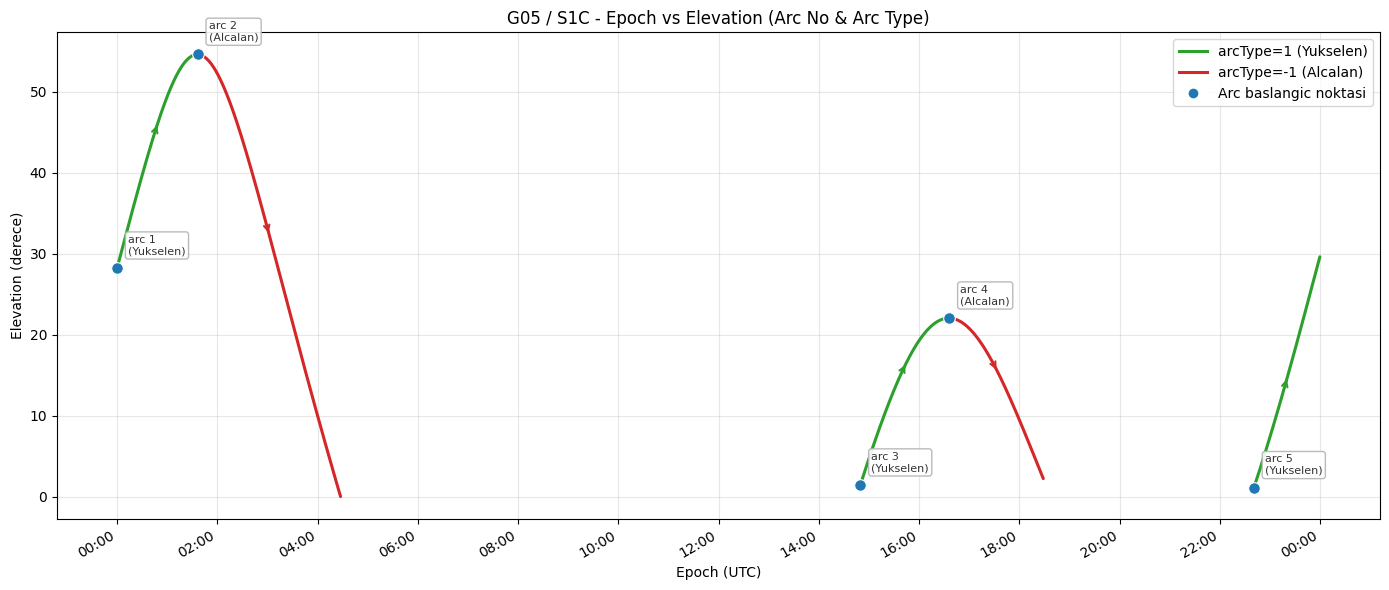

In [5]:
RISING_COLOR = "#2ca02c"
FALLING_COLOR = "#d62728"
ARC_START_COLOR = "#1f77b4"

fig, ax = plt.subplots(figsize=(14, 6))

legend_handles = []
seen_arc_types = set()

for arc_no, arc_group in plot_df.groupby("arcNo", sort=True):
    arc_group = arc_group.sort_values("epoch")
    arc_type = int(arc_group["arcType"].iloc[0])
    color = RISING_COLOR if arc_type == 1 else FALLING_COLOR
    direction_label = "Yukselen" if arc_type == 1 else "Alcalan"

    ax.plot(
        arc_group["epoch"],
        arc_group["elevation"],
        color=color,
        linewidth=2.2,
        solid_capstyle="round",
    )

    start_epoch = arc_group["epoch"].iloc[0]
    start_elev = arc_group["elevation"].iloc[0]
    ax.scatter(
        start_epoch,
        start_elev,
        s=70,
        color=ARC_START_COLOR,
        edgecolors="white",
        linewidths=0.8,
        zorder=5,
    )
    ax.annotate(
        f"arc {arc_no}\n({direction_label})",
        xy=(start_epoch, start_elev),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=8,
        color="#333333",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9),
    )

    if len(arc_group) >= 2:
        mid_idx = len(arc_group) // 2
        p0 = arc_group.iloc[mid_idx - 1]
        p1 = arc_group.iloc[mid_idx]
        dt = (p1["epoch"] - p0["epoch"]).total_seconds()
        if dt != 0:
            ax.annotate(
                "",
                xy=(p1["epoch"], p1["elevation"]),
                xytext=(p0["epoch"], p0["elevation"]),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=1.5,
                    shrinkA=0,
                    shrinkB=0,
                ),
            )

    if arc_type not in seen_arc_types:
        legend_handles.append(
            Line2D([0], [0], color=color, linewidth=2.2, label=f"arcType={arc_type} ({direction_label})")
        )
        seen_arc_types.add(arc_type)

legend_handles.append(
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=ARC_START_COLOR,
        markersize=8,
        label="Arc baslangic noktasi",
    )
)

ax.set_title(f"{target_sat} / {target_obs_type} - Epoch vs Elevation (Arc No & Arc Type)")
ax.set_xlabel("Epoch (UTC)")
ax.set_ylabel("Elevation (derece)")
ax.grid(True, alpha=0.3)
ax.legend(handles=legend_handles, loc="best")
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()